# BTC Feature Engineering and Volatility Regimes

**Author:** Sergej Schweizer  
**Date:** April 15, 2026

## Overview

This notebook loads BTC Deribit market data, engineers the regime-change features used in the project, and visualizes a set of simple rule-based volatility regimes.

## What This Notebook Does

- loads or refreshes the merged Deribit market dataset
- creates the enriched feature set used in downstream regime analysis
- saves the engineered dataset for later modeling steps
- visualizes returns, volatility, and simple high-volatility regime labels


## Table of Contents

- [How This Connects To The HMM Notebook](#How-This-Connects-To-The-HMM-Notebook)
- [New Features Created In This Notebook](#New-Features-Created-In-This-Notebook)
- [Statistic 1-2: Dataset Load And Engineered Feature Count](#Statistic-1-2-Dataset-Load-And-Engineered-Feature-Count)
- [Figure 1: Returns Versus Rolling Volatility](#Figure-1-Returns-Versus-Rolling-Volatility)
- [Statistic 3 And Figure 2: Binary High-Volatility Regime](#Statistic-3-And-Figure-2-Binary-High-Volatility-Regime)
- [Figure 3: Volatility Regimes With 72-Hour Shading](#Figure-3-Volatility-Regimes-With-72-Hour-Shading)


In [7]:
from src.regime_change_utils import (
    add_binary_high_vol_regime,
    engineer_regime_change_features,
    load_or_create_deribit_dataset,
    plot_binary_regime,
    plot_returns_vs_volatility,
    plot_volatility_regimes,
    save_enriched_dataset,
)


## How This Connects To The HMM Notebook

This notebook creates the observed feature vectors $x_t$ that are later passed into the HMM. In `01_regime_detection_and_hmm_analysis.ipynb`, the latent state variable $z_t \in \{1, \ldots, K\}$ is interpreted as an unobserved market regime, with:

- $P(z_t = j \mid z_{t-1} = i) = A_{ij}$
- $x_t \mid z_t = k \sim \mathcal{N}(\mu_k, \Sigma_k)$
- posterior regime probabilities $\gamma_{t,k} = P(z_t = k \mid x_{1:T})$

The model-selection rule used downstream is not predictive accuracy. A candidate is eligible only if it converged and if `min_state_fraction >= 0.05`, where

$$\text{min\_state\_fraction} = \min_k \frac{1}{T}\sum_{t=1}^T \mathbf{1}[\hat z_t = k]$$

and the main ranking score is

$$\text{selection\_score} = 3.0\,\text{avg\_self\_transition} + 1.5\,\text{min\_state\_fraction} - 0.25\,\text{median\_run\_length} - 2.5\,\text{avg\_entropy} + 0.05\,\text{loglik\_per\_obs\_per\_feature}$$

So this feature-engineering step matters because it directly determines the observed inputs whose latent-regime structure is later scored by that equation.


## New Features Created In This Notebook

The feature-engineering pipeline creates the following new columns from the raw Deribit market inputs.

Return-based features:

- log returns: `return_close_spot`, `return_close_perp`, `return_index_price`
- absolute returns: `abs_return_close_spot`, `abs_return_close_perp`, `abs_return_index_price`
- squared returns: `sq_return_close_spot`, `sq_return_close_perp`, `sq_return_index_price`

Volume features:

- log volume: `log_volume_spot`, `log_volume_perp`
- rolling means: `ma_24h_volume_spot`, `ma_72h_volume_spot`, `ma_24h_volume_perp`, `ma_72h_volume_perp`
- rolling standard deviations: `std_24h_volume_spot`, `std_72h_volume_spot`, `std_24h_volume_perp`, `std_72h_volume_perp`
- 24h z-scores: `z_24h_volume_spot`, `z_24h_volume_perp`
- 24h rates of change: `roc_24h_volume_spot`, `roc_24h_volume_perp`

Perpetual-cost and cross-market structure features:

- cost rolling features: `ma_24h_cost_perp`, `ma_72h_cost_perp`, `std_24h_cost_perp`, `std_72h_cost_perp`, `z_24h_cost_perp`
- cost changes and magnitude: `diff_1h_cost_perp`, `diff_8h_cost_perp`, `abs_cost_perp`
- spot/perp structure: `volume_perp_to_spot`, `perp_volume_share`, `volume_gap_perp_spot`, `log_volume_gap_perp_spot`
- interaction features: `cost_x_volume_perp`, `cost_perp_per_volume`, `abs_change_cost_24h`, `abs_change_volume_perp_24h`

Rolling volatility features:

- for each return-derived column above, the notebook adds 24h and 72h rolling standard deviations named `std_24h_<column>` and `std_72h_<column>`
- examples include `std_24h_return_close_spot`, `std_72h_return_close_perp`, and `std_72h_sq_return_close_perp`

ATR features:

- spot ATR: `ATR_24h_spot`, `ATR_72h_spot`, `ATR_24h_spot_norm`, `ATR_72h_spot_norm`
- perpetual ATR: `ATR_24h_perp`, `ATR_72h_perp`, `ATR_24h_perp_norm`, `ATR_72h_perp_norm`

Regime labels created later in the notebook:

- binary high-volatility label: `high_vol`
- high- and low-volatility shaded regions derived from `std_72h_return_close_spot`


In [8]:
DATA_CSV_PATH = 'data/deribit_data.csv'
ENRICHED_CSV_PATH = 'data/deribit_enriched_data.csv'

raw_df = load_or_create_deribit_dataset(
    csv_path=DATA_CSV_PATH,
    base_asset="BTC",
    lookback_days=365*5
    )
raw_df.head(3)


,open_spot,high_spot,low_spot,close_spot,volume_spot,cost_spot,open_perp,high_perp,low_perp,close_perp,volume_perp,cost_perp,index_price,interest_8h,interest_1h,prev_index_price
timestamp,,,,,,,,,,,,,,,,
2023-12-12 12:00:00+00:00,41819.99,41819.99,41819.99,41819.99,0.0112,468.383888,41590.5,41903.0,41590.5,41845.5,284.684758,11895930.0,41575.99,0.000083,9.306260e-07,41801.40
2023-12-12 13:00:00+00:00,41900.00,41900.00,41791.98,41870.00,3.1823,133157.488249,41855.0,42059.5,41752.0,41815.5,583.245790,24440950.0,41842.93,0.000066,7.146489e-06,41575.99
2023-12-12 14:00:00+00:00,41729.96,41730.00,41729.96,41730.00,0.0567,2366.090988,41815.0,41875.5,41301.0,41472.0,1110.233834,46157810.0,41798.09,0.000057,8.726458e-06,41842.93


In [9]:
df = engineer_regime_change_features(raw_df)
output_path = save_enriched_dataset(df, csv_path=ENRICHED_CSV_PATH)

print(f'Statistic 1. Engineered dataset saved to {output_path}')
print(f'Statistic 2. Total columns: {len(df.columns)}')
df.head(3)


Engineered dataset saved to data/deribit_enriched_data.csv
Total columns: 81


,open_spot,high_spot,low_spot,close_spot,volume_spot,cost_spot,open_perp,high_perp,low_perp,close_perp,...,std_72h_sq_return_close_perp,std_72h_sq_return_index_price,ATR_24h_spot,ATR_72h_spot,ATR_24h_spot_norm,ATR_72h_spot_norm,ATR_24h_perp,ATR_72h_perp,ATR_24h_perp_norm,ATR_72h_perp_norm
timestamp,,,,,,,,,,,,,,,,,,,,,
2023-12-12 12:00:00+00:00,41819.99,41819.99,41819.99,41819.99,0.0112,468.383888,41590.5,41903.0,41590.5,41845.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-12-12 13:00:00+00:00,41900.00,41900.00,41791.98,41870.00,3.1823,133157.488249,41855.0,42059.5,41752.0,41815.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-12-12 14:00:00+00:00,41729.96,41730.00,41729.96,41730.00,0.0567,2366.090988,41815.0,41875.5,41301.0,41472.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


The refactor keeps the engineered column names the downstream workflow already expects, but moves the long feature logic into `src/regime_change_utils.py` so the notebook stays focused on analysis.


(<Figure size 1400x600 with 2 Axes>,
 (<Axes: title={'center': 'Returns vs Rolling Volatility'}, xlabel='timestamp', ylabel='Returns'>,
  <Axes: xlabel='timestamp', ylabel='Volatility'>))

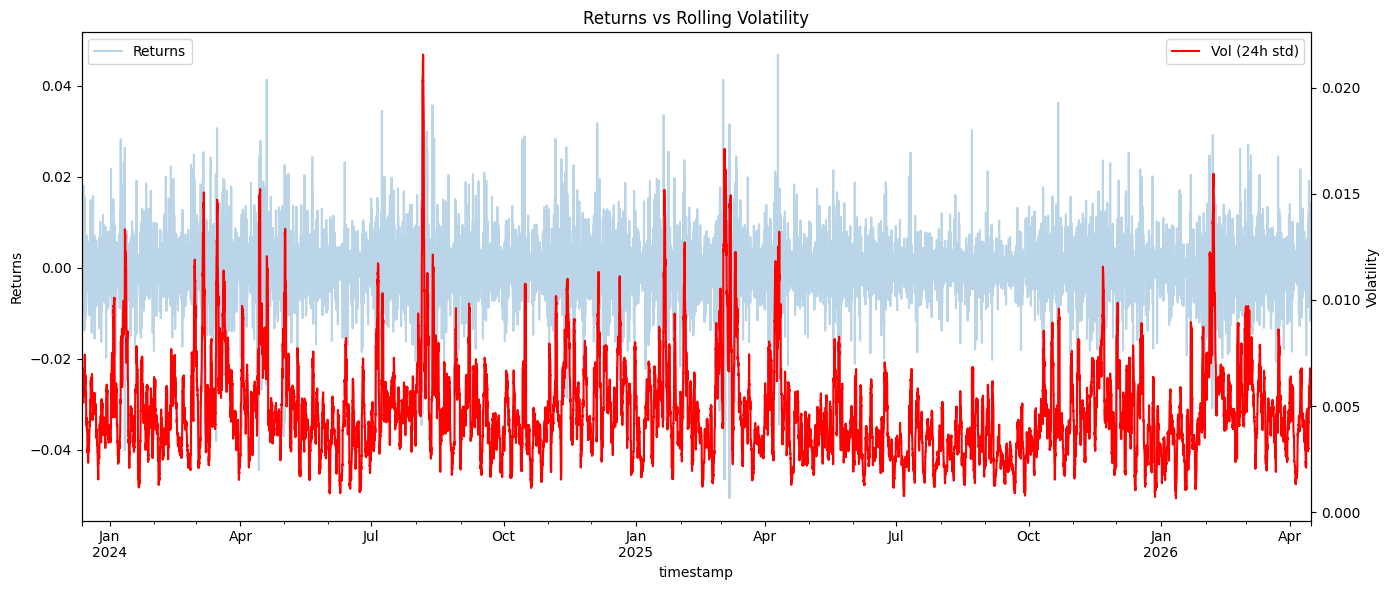

In [10]:
print('Figure 1. Returns versus rolling volatility')
plot_returns_vs_volatility(df)


**Figure 1 insight.** This chart shows that large hourly BTC return moves tend to arrive in clusters, and those clusters line up with rises in rolling 24-hour volatility. The main takeaway is that volatility is not random noise around returns: it concentrates during stressed periods, so a rolling-volatility feature can act as a simple first regime proxy.


High-volatility threshold (75th percentile): 0.005795


(<Figure size 1400x400 with 1 Axes>,
 <Axes: title={'center': 'High Volatility Regimes'}, ylabel='Regime'>)

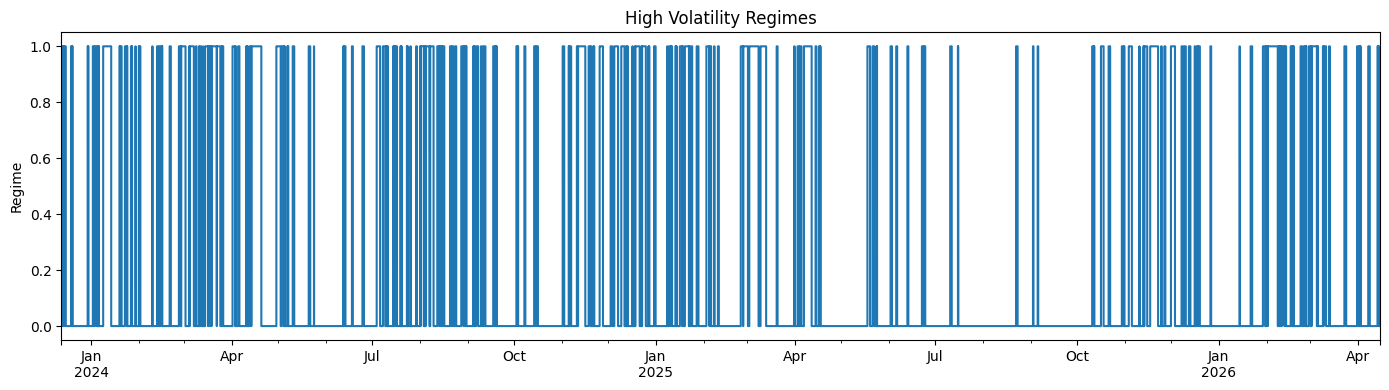

In [11]:
df, high_vol_threshold = add_binary_high_vol_regime(df)
print(f'Statistic 3. High-volatility threshold (75th percentile): {high_vol_threshold:.6f}')
print('Figure 2. Binary high-volatility regime')
plot_binary_regime(df)


**Figure 2 insight.** This step plot converts the continuous volatility signal into a simple on/off regime label. It makes clear when the market is being classified as unusually turbulent, how often that happens, and whether those episodes are isolated spikes or repeated clusters. The main benefit is interpretability: we can see exactly which timestamps the rule-based regime detector flags.


(<Figure size 1400x600 with 1 Axes>,
 <Axes: title={'center': 'Volatility Regimes (Based on 72h Std)'}, ylabel='Volatility'>)

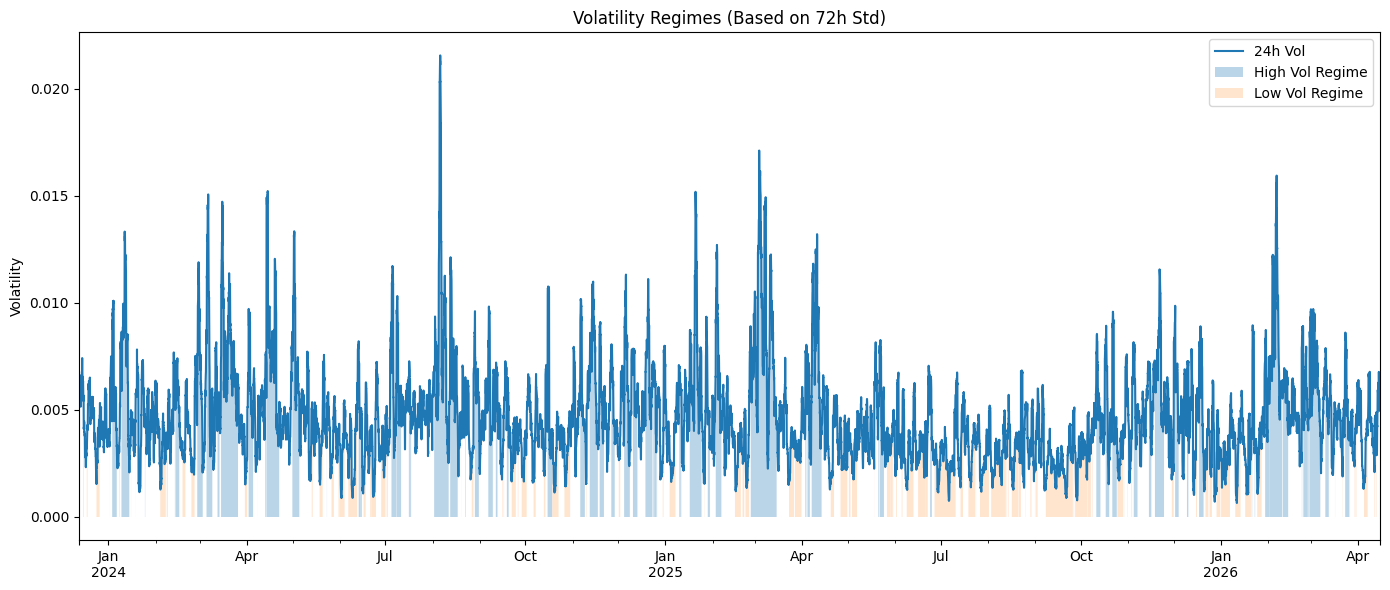

In [12]:
print('Figure 3. Volatility regimes with 72-hour regime shading')
plot_volatility_regimes(df)


**Figure 3 insight.** This visualization separates short-term noise from more persistent volatility structure. The fast 24-hour series shows local swings, while the slower 72-hour shading highlights broader calm and stressed intervals. The key takeaway is regime persistence: turbulent periods usually last for a while rather than appearing as one-off jumps, which is exactly the kind of structure later latent-regime models try to capture.
